In [2]:
# susceptibility_band_structure plot
# onlt t = 1.0 in square TB model
# the data used for this plot is zipped as suscep_band_structure_squareTB_ver2.0.zip

using JLD2
using Plots

mu_list = [0.0, 0.01, 0.1, 0.5, 1.0, 2.0, 3.0]

p = plot(title= "χ_density(t' = 0.0, square TB model)", size=(600, 450))
for mu in mu_list 
        N = 64 # for ver 2.0.
        file_name = "./raw_data/suscep_band_structure_$mu"*"_ver2.0.jld2"
        data = JLD2.load(file_name)
        chi_band_structure = data["chi_band_structure"]
        plot!(p, -real(chi_band_structure), label = "μ = $mu")
end
vline!([0, 2N, 3N], color=:black, linestyle=:dash, label = false)
xticks!([0, 2N, 3N, 4N],["M","Γ","X","M"])

display(p)
savefig(p, "figure/suscep_band_structure_squareTB_ver2.0.png")

ArgumentError: ArgumentError: No file exists at given path: ./raw_data/suscep_band_structure_0.0_ver2.0.jld2

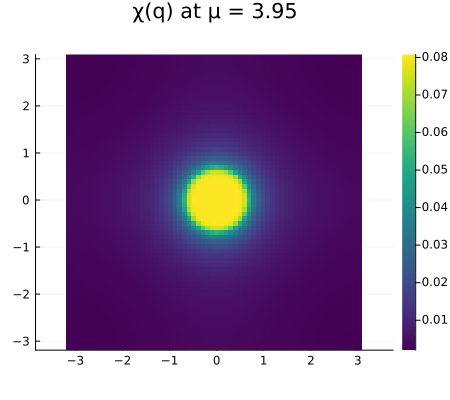

In [3]:
using Plots, JLD2

file_name = "./raw_data/static_suscep_BZmap_3.9_64x64.jld2"
data = JLD2.load(file_name)
chi_BZmap = data["chi_BZ_map"]
k_range =   data["k_range"]
p2 = heatmap(k_range, k_range, -real(chi_BZmap)', aspect_ratio=1, c=:viridis, title="χ(q) at μ = 3.95", size=(450, 400))

In [1]:
import PyPlot              # export 안 함 (충돌 예방)
const plt = PyPlot         # 관용적 별칭

using PyCall
const mpl = pyimport("matplotlib")  # rcParams, colormaps 등 접근용


PyObject <module 'matplotlib' from 'C:\\Users\\lucky\\.julia\\conda\\3\\x86_64\\Lib\\site-packages\\matplotlib\\__init__.py'>

In [2]:
mpl.rcParams["figure.dpi"] = 180
mpl.rcParams["savefig.dpi"] = 300
mpl.rcParams["figure.constrained_layout.use"] = true   # 여백 자동

mpl.rcParams["font.family"] = "DejaVu Sans"            # 원하면 "Helvetica"
mpl.rcParams["mathtext.fontset"] = "stix"
mpl.rcParams["font.size"] = 12
mpl.rcParams["axes.titlesize"] = 14
mpl.rcParams["axes.labelsize"] = 13

mpl.rcParams["lines.linewidth"] = 1.4    # 기본 선 두께
mpl.rcParams["legend.frameon"] = false   # 혹시 모를 흰 테두리 방지(전역)

mpl.rcParams["axes.linewidth"] = 1.0
mpl.rcParams["axes.labelpad"] = 6
mpl.rcParams["xtick.labelsize"] = 11
mpl.rcParams["ytick.labelsize"] = 11
mpl.rcParams["xtick.direction"] = "in"
mpl.rcParams["ytick.direction"] = "in"
mpl.rcParams["xtick.minor.visible"] = true
mpl.rcParams["ytick.minor.visible"] = true

mpl.rcParams["legend.fontsize"] = 9
mpl.rcParams["legend.frameon"] = false
mpl.rcParams["image.cmap"] = "magma"

# x라벨을 오른쪽 끝(1.0), 약간 아래; y라벨을 위쪽 끝(1.0), 약간 왼쪽
function move_labels_to_ends!(ax; xlab=nothing, ylab=nothing)
    if xlab !== nothing
        ax.set_xlabel(xlab)
        ax.xaxis.set_label_coords(1.0, -0.12)
    end
    if ylab !== nothing
        ax.set_ylabel(ylab)
        ax.yaxis.set_label_coords(-0.12, 1.0)
    end
    return ax
end

# ---- 축/눈금/범례 다듬기: '빈 범례' 안 만들도록 수정 ----
function beautify!(ax; legend_loc="lower right")
    for side in ["top","right","bottom","left"]
        ax.spines[side].set_linewidth(1.0)
    end
    ax.tick_params(which="both", length=4, width=1)

    # 핸들이 있을 때만 legend 생성 (히트맵의 '흰색 박스' 방지)
    handles, labels = ax.get_legend_handles_labels()
    if !isempty(labels)
        ax.legend(loc=legend_loc, fontsize=8,       # ★ 폰트 크기 (기본 9~10 → 더 작게)
                  labelspacing=0.2, # 항목 간 세로 간격 줄이기
                  handlelength=1.2, # 선 길이 줄이기
                  borderpad=0.3, frameon=true)  # 우하단 통일
    end
    return ax
end
# ---- 히트맵 축 눈금: ±π/2 간격 + (선택) 그리드 표시 ----
function set_pi_over2_ticks!(ax)
    vals = [-π, -π/2, 0.0, π/2, π]
    labs = ["\$-\\pi\$", "\$-\\pi/2\$", "\$0\$", "\$\\pi/2\$", "\$\\pi\$"]
    ax.set_xticks(vals); ax.set_xticklabels(labs)
    ax.set_yticks(vals); ax.set_yticklabels(labs)
    # 그리드도 원하시면 주석 해제
    ax.grid(true, which="major", alpha=0.25)
    return ax
end

set_pi_over2_ticks! (generic function with 1 method)

In [3]:
using JLD2

gap_types  = [:s_const, :s_ext, :dx2y2, :dxy, :px, :py]
colors     = Dict(:s_const=>"black", :s_ext=>"green", :dx2y2=>"red",
                  :dxy=>"purple", :px=>"blue", :py=>"royalblue")

# ---- 본문 그리는 부분: 선 얇게(lw=1.4), legend 우하단, 히트맵 눈금/흰박스 수정 ----
function plot_block!(ax1, ax2, ax3, data, μ, λ_end, k_range)
    U_range       = data["U_range"]
    lambda_gap_U  = data["lambda_gap_U"]
    lambda_diag_U = data["lambda_diag_U"]

    # (1) 전체 범위
    for (j, gt) in enumerate(gap_types)
        λ_proj_U = [row[j] for row in lambda_gap_U]
        ax1.plot(U_range, λ_proj_U, label=String(gt), lw=1.4, color=colors[gt])
    end
    λ_diag = [real(row[1]) for row in lambda_diag_U]
    ax1.plot(U_range, λ_diag, "--", color="black", label="diag", lw=1.4)
    ax1.set_ylim(-1.0, 1.0)
    ax1.set_title("LGE λ v.s. U (μ = $μ, $ver_name)")
    move_labels_to_ends!(ax1; xlab="U", ylab="λ")
    beautify!(ax1; legend_loc="lower right")   # ★ 우하단 고정

    # (2) 줌
    for (j, gt) in enumerate(gap_types)
        λ_proj_U = [row[j] for row in lambda_gap_U]
        ax2.plot(U_range, λ_proj_U, label=String(gt), lw=1.4, color=colors[gt])
    end
    ax2.plot(U_range, λ_diag, "--", color="black", label="diag", lw=1.4)
    ax2.set_ylim(-λ_end, λ_end)
    ax2.set_title("zoom")
    move_labels_to_ends!(ax2; xlab="U", ylab="λ")
    beautify!(ax2; legend_loc="lower right")   # ★ 우하단 고정

    # (3) 히트맵
    N = length(U_range)
    eigvec_half = lambda_diag_U[div(N,2)][2]
    who_win     = lambda_diag_U[div(N,2)][3]
    im = ax3.imshow(real(permutedims(eigvec_half)),
                    extent=[minimum(k_range), maximum(k_range),
                            minimum(k_range), maximum(k_range)],
                    origin="lower", aspect="auto", interpolation="none")
    # 컬러바
    fig = ax3.figure
    cbar = fig.colorbar(im, ax=ax3, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=9)

    ax3.set_title("Diag. Eigvec (U = $(round(U_range[div(N,2)]))): $who_win")
    move_labels_to_ends!(ax3; xlab="kx", ylab="ky")
    set_pi_over2_ticks!(ax3)                  # ★ π/2 간격 눈금/그리드
    beautify!(ax3)                            # 핸들 없으니 legend 생성 안 함(흰 박스 제거)
end


plot_block! (generic function with 1 method)

In [7]:

# 사용 예
μ_list = [0.5, 3.95]; λ_end_list = [0.1, 0.1]
ver_name = "spect"   # "tanh" or "spect"

k_range = collect(LinRange(-pi, pi, 65))[1:end-1]

fig = plt.figure(figsize=(14, 9), constrained_layout=true)
axs = [fig.add_subplot(2,3,i) for i in 1:6]

for (i, μ) in enumerate(μ_list)
    data = JLD2.load("./raw_data/LGE_$(μ)."*ver_name*".jld2")
    plot_block!(axs[3(i-1)+1], axs[3(i-1)+2], axs[3(i-1)+3],
                data, μ, λ_end_list[i], k_range)
end

fig_name_string = "LGE λ vs U ($ver_name) with 3.95.png"
fig.savefig(fig_name_string, dpi=400, bbox_inches="tight")
